# 06 — Baseline Monthly Time-Series Association Models

This notebook estimates baseline monthly time-series association models for Texas.

The main outcome is the CPI-adjusted residential electricity price. The explanatory variables include:

- Henry Hub natural-gas prices;
- natural-gas and renewable generation shares;
- heating and cooling degree days;
- month-of-year controls;
- a linear time trend.

Heteroskedasticity and autocorrelation-consistent standard errors are used where appropriate.

The estimates describe monthly associations and should not be interpreted as causal effects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson


CURRENT_DIRECTORY = Path.cwd()

if (CURRENT_DIRECTORY / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
elif (CURRENT_DIRECTORY.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. "
        f"Current directory: {CURRENT_DIRECTORY}"
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "tx_energy_economy_analysis_sample.csv"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The final analysis sample was not found. "
        "Run `python src/build_analysis_sample.py` first."
    )

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["period"],
)

df = (
    df
    .sort_values("period")
    .reset_index(drop=True)
)

if df["period"].duplicated().any():
    raise ValueError(
        "Duplicate monthly observations were found."
    )

expected_periods = pd.date_range(
    start=df["period"].min(),
    end=df["period"].max(),
    freq="MS",
)

missing_periods = expected_periods.difference(
    pd.DatetimeIndex(df["period"])
)

if len(missing_periods) > 0:
    raise ValueError(
        "Missing calendar months were found: "
        f"{missing_periods.strftime('%Y-%m').tolist()}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(
    "Date range: "
    f"{df['period'].min():%Y-%m} to "
    f"{df['period'].max():%Y-%m}"
)

df.head()

Project root: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor
Rows: 137
Columns: 121
Date range: 2015-01 to 2026-05


,period,commercial_customers,commercial_price,commercial_revenue,commercial_sales,industrial_customers,industrial_price,industrial_revenue,industrial_sales,residential_customers,...,commercial_price_real_2025_01,industrial_price_real_2025_01,tx_cooling_degree_days,tx_heating_degree_days,tx_precipitation,tx_average_temperature,tx_cooling_degree_days_departure,tx_heating_degree_days_departure,tx_precipitation_departure,tx_average_temperature_departure
0,2015-01-01,1424841.0,8.40,910.06698,10834.88707,97914.0,5.93,502.67896,8481.28780,10236358.0,...,11.413447,8.057350,5,583,2.67,44.0,-9,44,1.18,-1.4
1,2015-02-01,1414177.0,8.50,842.24433,9903.83625,101493.0,5.84,471.33029,8076.96359,10222635.0,...,11.520122,7.915001,7,429,1.09,48.2,-8,43,-0.51,-1.2
2,2015-03-01,1421352.0,8.49,895.83199,10548.75206,102666.0,5.79,502.20327,8667.54624,10292791.0,...,11.475654,7.826153,40,250,3.47,56.2,-12,-3,1.81,-0.1
3,2015-04-01,1417183.0,7.98,840.64570,10540.04355,104227.0,5.54,491.40865,8870.68519,10302930.0,...,10.775071,7.480438,157,40,3.96,66.6,45,-26,1.60,1.8
4,2015-05-01,1411987.0,8.21,868.98021,10588.54603,105413.0,5.56,507.11835,9122.37774,10288519.0,...,11.049193,7.482767,283,8,9.05,71.6,7,2,5.68,-0.9


In [2]:
MODEL_VARIABLES = [
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "natural_gas_share",
    "renewable_share",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
]

missing_columns = [
    column
    for column in MODEL_VARIABLES
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "Required model variables are missing: "
        f"{missing_columns}"
    )

variable_coverage = pd.DataFrame(
    {
        "observed": df[MODEL_VARIABLES].notna().sum(),
        "missing": df[MODEL_VARIABLES].isna().sum(),
    }
)

variable_coverage

,observed,missing
residential_price_real_2025_01,136,1
henry_hub_natural_gas_price,137,0
natural_gas_share,137,0
renewable_share,137,0
tx_heating_degree_days,137,0
tx_cooling_degree_days,137,0


In [3]:
analysis_df = df[
    [
        "period",
        *MODEL_VARIABLES,
    ]
].copy()

# Preserve the actual monthly time position before dropping missing values.
analysis_df["time_trend"] = np.arange(
    len(analysis_df)
)

analysis_df["month_of_year"] = (
    analysis_df["period"]
    .dt.month
    .astype("category")
)

# Convert generation shares from proportions to percentage-point units.
analysis_df["natural_gas_share_pp"] = (
    analysis_df["natural_gas_share"] * 100
)

analysis_df["renewable_share_pp"] = (
    analysis_df["renewable_share"] * 100
)

ESTIMATION_VARIABLES = [
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
]

model_df = (
    analysis_df
    .dropna(
        subset=ESTIMATION_VARIABLES
    )
    .reset_index(drop=True)
)

print(f"Full analysis sample: {len(analysis_df)} months")
print(f"Unified estimation sample: {len(model_df)} months")
print(
    "Estimation period: "
    f"{model_df['period'].min():%Y-%m} to "
    f"{model_df['period'].max():%Y-%m}"
)

model_df.head()

Full analysis sample: 137 months
Unified estimation sample: 136 months
Estimation period: 2015-01 to 2026-05


,period,residential_price_real_2025_01,henry_hub_natural_gas_price,natural_gas_share,renewable_share,tx_heating_degree_days,tx_cooling_degree_days,time_trend,month_of_year,natural_gas_share_pp,renewable_share_pp
0,2015-01-01,15.611965,2.99,0.506177,0.086717,583,5,0,1,50.617738,8.671679
1,2015-02-01,15.748684,2.87,0.510098,0.103470,429,7,1,2,51.009847,10.347001
2,2015-03-01,15.625272,2.83,0.570979,0.083440,250,40,2,3,57.097939,8.343953
3,2015-04-01,16.338140,2.61,0.543158,0.137147,40,157,3,4,54.315777,13.714729
4,2015-05-01,16.203689,2.85,0.503118,0.129752,8,283,4,5,50.311756,12.975173


## 1. Estimation-sample overview

Before estimating the regression models, this section summarizes the variables and examines their monthly time-series patterns.

February 2021 is highlighted because Winter Storm Uri caused an exceptional disruption in the Texas energy market.

In [4]:
SUMMARY_VARIABLES = [
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
]

summary_statistics = (
    model_df[SUMMARY_VARIABLES]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max",
        ]
    )
    .T
    .round(3)
)

summary_statistics.to_csv(
    TABLE_DIRECTORY
    / "baseline_model_summary_statistics.csv"
)

summary_statistics

,count,mean,std,min,median,max
residential_price_real_2025_01,136.0,14.841,0.580,13.624,14.692,16.338
henry_hub_natural_gas_price,136.0,3.167,1.380,1.490,2.830,8.810
natural_gas_share_pp,136.0,49.530,5.330,36.810,50.117,60.617
renewable_share_pp,136.0,22.578,8.573,7.379,22.072,45.454
tx_heating_degree_days,136.0,138.669,175.583,0.000,45.000,609.000
tx_cooling_degree_days,136.0,252.096,228.143,5.000,157.500,747.000


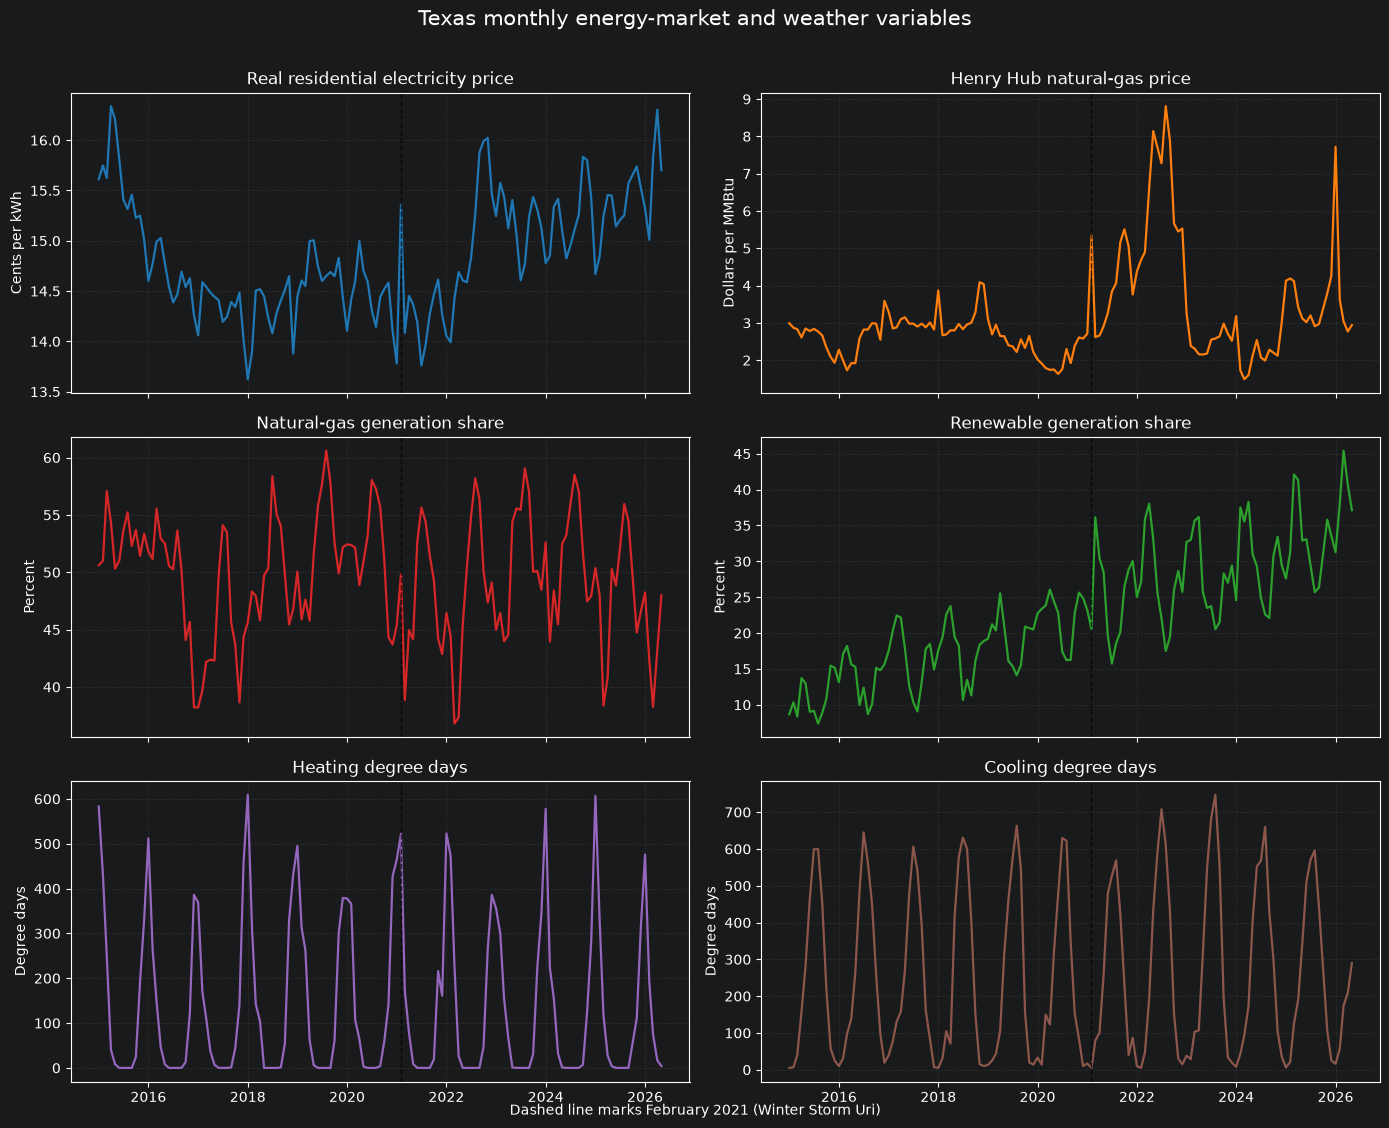

Figure saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\figures\baseline_model_variable_trends.png


In [5]:
PLOT_CONFIG = {
    "residential_price_real_2025_01": {
        "title": "Real residential electricity price",
        "ylabel": "Cents per kWh",
        "color": "tab:blue",
    },
    "henry_hub_natural_gas_price": {
        "title": "Henry Hub natural-gas price",
        "ylabel": "Dollars per MMBtu",
        "color": "tab:orange",
    },
    "natural_gas_share_pp": {
        "title": "Natural-gas generation share",
        "ylabel": "Percent",
        "color": "tab:red",
    },
    "renewable_share_pp": {
        "title": "Renewable generation share",
        "ylabel": "Percent",
        "color": "tab:green",
    },
    "tx_heating_degree_days": {
        "title": "Heating degree days",
        "ylabel": "Degree days",
        "color": "tab:purple",
    },
    "tx_cooling_degree_days": {
        "title": "Cooling degree days",
        "ylabel": "Degree days",
        "color": "tab:brown",
    },
}

URI_MONTH = pd.Timestamp("2021-02-01")

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 11),
    sharex=True,
)

for ax, (variable, settings) in zip(
    axes.flat,
    PLOT_CONFIG.items(),
):
    ax.plot(
        model_df["period"],
        model_df[variable],
        color=settings["color"],
        linewidth=1.6,
    )

    ax.axvline(
        URI_MONTH,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    ax.set_title(settings["title"])
    ax.set_ylabel(settings["ylabel"])
    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

fig.suptitle(
    "Texas monthly energy-market and weather variables",
    fontsize=15,
    y=1.01,
)

fig.text(
    0.5,
    0.005,
    "Dashed line marks February 2021 (Winter Storm Uri)",
    ha="center",
    fontsize=10,
)

fig.tight_layout()

FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "baseline_model_variable_trends.png"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {FIGURE_PATH}")

In [6]:
URI_WINDOW_START = pd.Timestamp("2020-11-01")
URI_WINDOW_END = pd.Timestamp("2021-05-01")

uri_window = (
    model_df.loc[
        model_df["period"].between(
            URI_WINDOW_START,
            URI_WINDOW_END,
        ),
        [
            "period",
            *SUMMARY_VARIABLES,
        ],
    ]
    .set_index("period")
    .round(3)
)

uri_window

,residential_price_real_2025_01,henry_hub_natural_gas_price,natural_gas_share_pp,renewable_share_pp,tx_heating_degree_days,tx_cooling_degree_days
period,,,,,,
2020-11-01,14.584,2.61,44.338,25.638,141,84
2020-12-01,14.107,2.58,43.707,24.873,427,10
2021-01-01,13.781,2.71,45.391,23.232,465,17
2021-02-01,15.356,5.35,49.868,20.489,522,5
2021-03-01,14.085,2.62,38.866,36.154,173,79
2021-04-01,14.452,2.66,44.950,30.434,78,101
2021-05-01,14.368,2.91,44.162,28.491,9,257


## 2. Baseline association models

Four nested models are estimated on the same monthly sample:

1. Henry Hub natural-gas price only;
2. generation-mix controls added;
3. weather controls added;
4. month-of-year fixed effects and a linear time trend added.

All models use heteroskedasticity and autocorrelation-consistent standard errors with a maximum lag length of 12 months.

The coefficients represent conditional monthly associations rather than causal effects.

In [7]:
OUTCOME_VARIABLE = (
    "residential_price_real_2025_01"
)

MODEL_FORMULAS = {
    "Model 1": (
        f"{OUTCOME_VARIABLE} "
        "~ henry_hub_natural_gas_price"
    ),
    "Model 2": (
        f"{OUTCOME_VARIABLE} "
        "~ henry_hub_natural_gas_price "
        "+ natural_gas_share_pp "
        "+ renewable_share_pp"
    ),
    "Model 3": (
        f"{OUTCOME_VARIABLE} "
        "~ henry_hub_natural_gas_price "
        "+ natural_gas_share_pp "
        "+ renewable_share_pp "
        "+ tx_heating_degree_days "
        "+ tx_cooling_degree_days"
    ),
    "Model 4": (
        f"{OUTCOME_VARIABLE} "
        "~ henry_hub_natural_gas_price "
        "+ natural_gas_share_pp "
        "+ renewable_share_pp "
        "+ tx_heating_degree_days "
        "+ tx_cooling_degree_days "
        "+ time_trend "
        "+ C(month_of_year)"
    ),
}

for model_name, formula in MODEL_FORMULAS.items():
    print(f"{model_name}:")
    print(f"  {formula}")

Model 1:
  residential_price_real_2025_01 ~ henry_hub_natural_gas_price
Model 2:
  residential_price_real_2025_01 ~ henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp
Model 3:
  residential_price_real_2025_01 ~ henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days
Model 4:
  residential_price_real_2025_01 ~ henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days + time_trend + C(month_of_year)


In [8]:
HAC_MAX_LAGS = 12

baseline_models = {}

for model_name, formula in MODEL_FORMULAS.items():
    fitted_model = (
        smf.ols(
            formula=formula,
            data=model_df,
        )
        .fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAX_LAGS,
                "use_correction": True,
            },
        )
    )

    baseline_models[model_name] = fitted_model

print(
    f"Estimated {len(baseline_models)} models "
    f"with HAC({HAC_MAX_LAGS}) standard errors."
)

for model_name, result in baseline_models.items():
    print(
        f"{model_name}: "
        f"N = {int(result.nobs)}, "
        f"R² = {result.rsquared:.3f}, "
        f"Adjusted R² = {result.rsquared_adj:.3f}"
    )

Estimated 4 models with HAC(12) standard errors.
Model 1: N = 136, R² = 0.002, Adjusted R² = -0.006
Model 2: N = 136, R² = 0.155, Adjusted R² = 0.136
Model 3: N = 136, R² = 0.275, Adjusted R² = 0.248
Model 4: N = 136, R² = 0.311, Adjusted R² = 0.211


In [9]:
from statsmodels.iolib.summary2 import summary_col


MODEL_ORDER = [
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
]

REGRESSOR_ORDER = [
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "Intercept",
]

REGRESSOR_LABELS = {
    "henry_hub_natural_gas_price": "Henry Hub gas price",
    "natural_gas_share_pp": "Natural-gas share",
    "renewable_share_pp": "Renewable share",
    "tx_heating_degree_days": "Heating degree days",
    "tx_cooling_degree_days": "Cooling degree days",
    "time_trend": "Linear time trend",
    "Intercept": "Constant",
}

regression_table = summary_col(
    results=[
        baseline_models[name]
        for name in MODEL_ORDER
    ],
    model_names=MODEL_ORDER,
    stars=True,
    float_format="%0.3f",
    regressor_order=REGRESSOR_ORDER,
    info_dict={
        "Observations": lambda result: (
            f"{int(result.nobs)}"
        ),
        "R-squared": lambda result: (
            f"{result.rsquared:.3f}"
        ),
        "Adjusted R-squared": lambda result: (
            f"{result.rsquared_adj:.3f}"
        ),
        "Month fixed effects": lambda result: (
            "Yes"
            if "C(month_of_year)" in result.model.formula
            else "No"
        ),
        "Time trend": lambda result: (
            "Yes"
            if "time_trend" in result.model.formula
            else "No"
        ),
        "HAC maximum lag": lambda result: (
            str(HAC_MAX_LAGS)
        ),
    },
)

regression_table

,Model 1,Model 2,Model 3,Model 4
henry_hub_natural_gas_price,0.017,0.009,0.058,0.052
,(0.051),(0.047),(0.045),(0.049)
natural_gas_share_pp,,0.035***,0.061***,0.054***
,,(0.009),(0.014),(0.020)
renewable_share_pp,,0.030*,0.025,-0.004
,,(0.016),(0.016),(0.025)
tx_heating_degree_days,,,-0.002***,-0.002*
,,,(0.000),(0.001)
tx_cooling_degree_days,,,-0.002***,0.000
,,,(0.000),(0.002)


In [10]:
CORE_REGRESSORS = [
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
]

coefficient_rows = []

for model_name in MODEL_ORDER:
    result = baseline_models[model_name]

    for variable in CORE_REGRESSORS:
        if variable not in result.params.index:
            continue

        confidence_interval = (
            result.conf_int()
            .loc[variable]
        )

        coefficient_rows.append(
            {
                "model": model_name,
                "variable": variable,
                "label": REGRESSOR_LABELS[variable],
                "coefficient": result.params[variable],
                "hac_standard_error": result.bse[variable],
                "t_statistic": result.tvalues[variable],
                "p_value": result.pvalues[variable],
                "confidence_interval_95_lower": (
                    confidence_interval.iloc[0]
                ),
                "confidence_interval_95_upper": (
                    confidence_interval.iloc[1]
                ),
                "observations": int(result.nobs),
                "r_squared": result.rsquared,
                "adjusted_r_squared": (
                    result.rsquared_adj
                ),
            }
        )

baseline_coefficient_table = (
    pd.DataFrame(coefficient_rows)
    .round(4)
)

COEFFICIENT_TABLE_PATH = (
    TABLE_DIRECTORY
    / "baseline_model_coefficients.csv"
)

baseline_coefficient_table.to_csv(
    COEFFICIENT_TABLE_PATH,
    index=False,
)

baseline_coefficient_table

,model,variable,label,coefficient,hac_standard_error,t_statistic,p_value,confidence_interval_95_lower,confidence_interval_95_upper,observations,r_squared,adjusted_r_squared
0,Model 1,henry_hub_natural_gas_price,Henry Hub gas price,0.0173,0.0510,0.3388,0.7348,-0.0826,0.1171,136,0.0017,-0.0058
1,Model 2,henry_hub_natural_gas_price,Henry Hub gas price,0.0090,0.0468,0.1921,0.8477,-0.0827,0.1007,136,0.1549,0.1357
2,Model 2,natural_gas_share_pp,Natural-gas share,0.0347,0.0087,4.0087,0.0001,0.0178,0.0517,136,0.1549,0.1357
3,Model 2,renewable_share_pp,Renewable share,0.0298,0.0155,1.9190,0.0550,-0.0006,0.0602,136,0.1549,0.1357
4,Model 3,henry_hub_natural_gas_price,Henry Hub gas price,0.0584,0.0449,1.3000,0.1936,-0.0297,0.1465,136,0.2755,0.2476
5,Model 3,natural_gas_share_pp,Natural-gas share,0.0611,0.0144,4.2439,0.0000,0.0329,0.0893,136,0.2755,0.2476
6,Model 3,renewable_share_pp,Renewable share,0.0246,0.0157,1.5636,0.1179,-0.0062,0.0554,136,0.2755,0.2476
7,Model 3,tx_heating_degree_days,Heating degree days,-0.0017,0.0003,-5.4734,0.0000,-0.0024,-0.0011,136,0.2755,0.2476
8,Model 3,tx_cooling_degree_days,Cooling degree days,-0.0018,0.0004,-4.2959,0.0000,-0.0026,-0.0010,136,0.2755,0.2476
9,Model 4,henry_hub_natural_gas_price,Henry Hub gas price,0.0517,0.0487,1.0618,0.2883,-0.0437,0.1471,136,0.3107,0.2114


In [11]:
REGRESSION_TABLE_PATH = (
    TABLE_DIRECTORY
    / "baseline_model_results.html"
)

REGRESSION_TABLE_PATH.write_text(
    regression_table.as_html(),
    encoding="utf-8",
)

print(
    f"Coefficient table saved to: "
    f"{COEFFICIENT_TABLE_PATH}"
)

print(
    f"Regression table saved to: "
    f"{REGRESSION_TABLE_PATH}"
)

Coefficient table saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\baseline_model_coefficients.csv
Regression table saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\baseline_model_results.html


## 3. Model diagnostics

This section evaluates the residual behavior and specification of the baseline models.

The diagnostics include:

- Durbin–Watson statistics;
- Ljung–Box tests for residual autocorrelation;
- residual autocorrelation plots;
- variance inflation factors;
- influential-observation measures.

Model 4 is treated as the preferred baseline specification because it includes the full set of controls, month-of-year fixed effects, and a linear time trend.

In [12]:
DIAGNOSTIC_LAGS = [
    1,
    6,
    12,
]

diagnostic_rows = []
ljung_box_tables = []

for model_name in MODEL_ORDER:
    result = baseline_models[model_name]
    residuals = result.resid

    diagnostic_rows.append(
        {
            "model": model_name,
            "durbin_watson": durbin_watson(
                residuals
            ),
            "residual_mean": residuals.mean(),
            "residual_standard_deviation": (
                residuals.std(ddof=1)
            ),
        }
    )

    ljung_box_result = acorr_ljungbox(
        residuals,
        lags=DIAGNOSTIC_LAGS,
        return_df=True,
    )

    ljung_box_result = (
        ljung_box_result
        .reset_index()
        .rename(
            columns={
                "index": "lag",
                "lb_stat": "ljung_box_statistic",
                "lb_pvalue": "p_value",
            }
        )
    )

    ljung_box_result.insert(
        0,
        "model",
        model_name,
    )

    ljung_box_tables.append(
        ljung_box_result
    )

residual_diagnostics = (
    pd.DataFrame(diagnostic_rows)
    .round(4)
)

ljung_box_diagnostics = (
    pd.concat(
        ljung_box_tables,
        ignore_index=True,
    )
    .round(4)
)

display(residual_diagnostics)
display(ljung_box_diagnostics)

,model,durbin_watson,residual_mean,residual_standard_deviation
0,Model 1,0.3519,-0.0,0.5798
1,Model 2,0.4193,0.0,0.5334
2,Model 3,0.4213,-0.0,0.4939
3,Model 4,0.3780,-0.0,0.4818


,model,lag,ljung_box_statistic,p_value
0,Model 1,1,91.0382,0.0
1,Model 1,6,326.2682,0.0
2,Model 1,12,432.6758,0.0
3,Model 2,1,82.4603,0.0
4,Model 2,6,258.5092,0.0
5,Model 2,12,305.0205,0.0
6,Model 3,1,79.5993,0.0
7,Model 3,6,298.6609,0.0
8,Model 3,12,360.4318,0.0
9,Model 4,1,83.9039,0.0


In [13]:
RESIDUAL_DIAGNOSTICS_PATH = (
    TABLE_DIRECTORY
    / "baseline_residual_diagnostics.csv"
)

LJUNG_BOX_PATH = (
    TABLE_DIRECTORY
    / "baseline_ljung_box_tests.csv"
)

residual_diagnostics.to_csv(
    RESIDUAL_DIAGNOSTICS_PATH,
    index=False,
)

ljung_box_diagnostics.to_csv(
    LJUNG_BOX_PATH,
    index=False,
)

print(
    f"Residual diagnostics saved to: "
    f"{RESIDUAL_DIAGNOSTICS_PATH}"
)

print(
    f"Ljung–Box tests saved to: "
    f"{LJUNG_BOX_PATH}"
)

Residual diagnostics saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\baseline_residual_diagnostics.csv
Ljung–Box tests saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\baseline_ljung_box_tests.csv


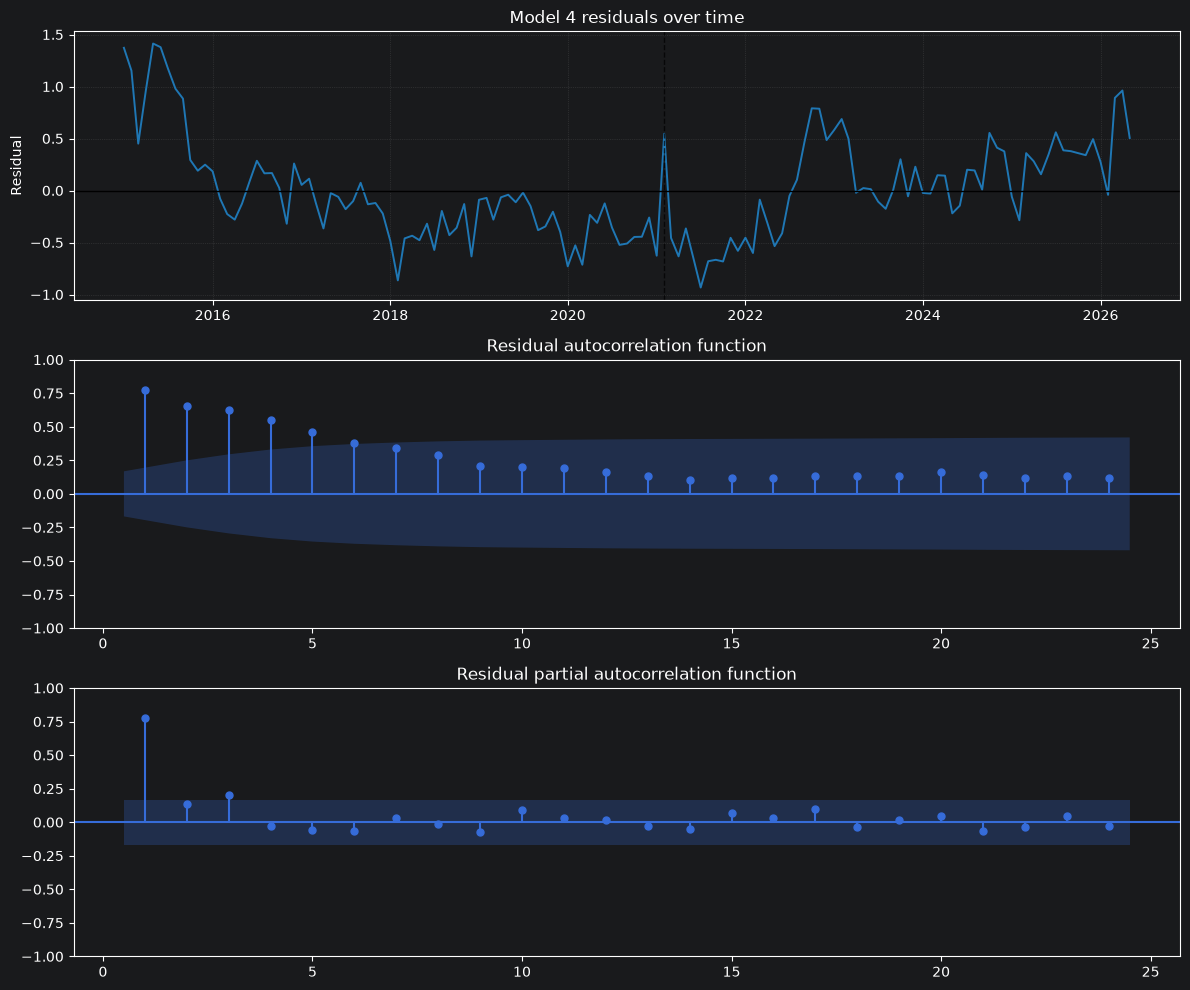

Residual figure saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\figures\baseline_model_4_residual_diagnostics.png


In [14]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


PREFERRED_MODEL_NAME = "Model 4"
preferred_model = baseline_models[
    PREFERRED_MODEL_NAME
]

preferred_residuals = pd.Series(
    preferred_model.resid.to_numpy(),
    index=model_df["period"],
    name="residual",
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
)

axes[0].plot(
    preferred_residuals.index,
    preferred_residuals,
    color="tab:blue",
    linewidth=1.4,
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1,
)

axes[0].axvline(
    URI_MONTH,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

axes[0].set_title(
    "Model 4 residuals over time"
)

axes[0].set_ylabel(
    "Residual"
)

axes[0].grid(
    alpha=0.25,
    linestyle=":",
)

plot_acf(
    preferred_residuals,
    lags=24,
    zero=False,
    ax=axes[1],
)

axes[1].set_title(
    "Residual autocorrelation function"
)

plot_pacf(
    preferred_residuals,
    lags=24,
    zero=False,
    method="ywm",
    ax=axes[2],
)

axes[2].set_title(
    "Residual partial autocorrelation function"
)

fig.tight_layout()

RESIDUAL_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "baseline_model_4_residual_diagnostics.png"
)

fig.savefig(
    RESIDUAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Residual figure saved to: "
    f"{RESIDUAL_FIGURE_PATH}"
)

In [15]:
model_4_design_matrix = pd.DataFrame(
    preferred_model.model.exog,
    columns=preferred_model.model.exog_names,
)

vif_rows = []

for column_index, column_name in enumerate(
    model_4_design_matrix.columns
):
    vif_rows.append(
        {
            "variable": column_name,
            "vif": variance_inflation_factor(
                model_4_design_matrix.to_numpy(),
                column_index,
            ),
        }
    )

vif_table = (
    pd.DataFrame(vif_rows)
    .query("variable != 'Intercept'")
    .sort_values(
        "vif",
        ascending=False,
    )
    .reset_index(drop=True)
)

vif_table["vif"] = (
    vif_table["vif"]
    .round(3)
)

VIF_TABLE_PATH = (
    TABLE_DIRECTORY
    / "baseline_model_4_vif.csv"
)

vif_table.to_csv(
    VIF_TABLE_PATH,
    index=False,
)

vif_table

,variable,vif
0,tx_cooling_degree_days,37.148
1,renewable_share_pp,28.219
2,C(month_of_year)[T.8],24.254
3,C(month_of_year)[T.7],23.034
4,time_trend,18.832
5,C(month_of_year)[T.6],17.328
6,C(month_of_year)[T.9],17.099
7,tx_heating_degree_days,16.233
8,C(month_of_year)[T.5],11.382
9,C(month_of_year)[T.10],8.444


In [16]:
CORE_VIF_VARIABLES = [
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
]

core_vif_table = vif_table.loc[
    vif_table["variable"].isin(
        CORE_VIF_VARIABLES
    )
].copy()

core_vif_table

,variable,vif
0,tx_cooling_degree_days,37.148
1,renewable_share_pp,28.219
4,time_trend,18.832
7,tx_heating_degree_days,16.233
13,natural_gas_share_pp,3.907
16,henry_hub_natural_gas_price,1.286


In [17]:
# Refit Model 4 with conventional covariance only for
# influence diagnostics. Coefficients and residuals are
# identical to those in the HAC model.
model_4_diagnostic_fit = smf.ols(
    formula=MODEL_FORMULAS[
        PREFERRED_MODEL_NAME
    ],
    data=model_df,
).fit()

influence = (
    model_4_diagnostic_fit
    .get_influence()
)

influence_summary = (
    influence
    .summary_frame()
    .reset_index(drop=True)
)

influence_table = pd.concat(
    [
        model_df[
            [
                "period",
                OUTCOME_VARIABLE,
            ]
        ].reset_index(drop=True),
        influence_summary[
            [
                "standard_resid",
                "student_resid",
                "hat_diag",
                "cooks_d",
            ]
        ],
    ],
    axis=1,
)

NUMBER_OF_PARAMETERS = (
    model_4_diagnostic_fit
    .model
    .exog
    .shape[1]
)

NUMBER_OF_OBSERVATIONS = int(
    model_4_diagnostic_fit.nobs
)

COOKS_DISTANCE_THRESHOLD = (
    4 / NUMBER_OF_OBSERVATIONS
)

LEVERAGE_THRESHOLD = (
    2
    * NUMBER_OF_PARAMETERS
    / NUMBER_OF_OBSERVATIONS
)

influence_table[
    "large_studentized_residual"
] = (
    influence_table[
        "student_resid"
    ].abs() > 2
)

influence_table[
    "high_cooks_distance"
] = (
    influence_table["cooks_d"]
    > COOKS_DISTANCE_THRESHOLD
)

influence_table[
    "high_leverage"
] = (
    influence_table["hat_diag"]
    > LEVERAGE_THRESHOLD
)

influential_months = (
    influence_table.loc[
        (
            influence_table[
                "large_studentized_residual"
            ]
            | influence_table[
                "high_cooks_distance"
            ]
            | influence_table[
                "high_leverage"
            ]
        )
    ]
    .sort_values(
        "cooks_d",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Cook's-distance threshold: "
    f"{COOKS_DISTANCE_THRESHOLD:.4f}"
)

print(
    "Leverage threshold: "
    f"{LEVERAGE_THRESHOLD:.4f}"
)

influential_months.head(15)

Cook's-distance threshold: 0.0294
Leverage threshold: 0.2647


,period,residential_price_real_2025_01,standard_resid,student_resid,hat_diag,cooks_d,large_studentized_residual,high_cooks_distance,high_leverage
0,2015-01-01,15.611965,2.843929,2.934195,0.123299,0.063194,True,True,False
1,2015-06-01,15.810014,2.846224,2.936737,0.117128,0.059707,True,True,False
2,2015-05-01,16.203689,2.907660,3.004964,0.110220,0.058182,True,True,False
3,2015-02-01,15.748684,2.398252,2.448487,0.130235,0.047846,True,True,False
4,2015-07-01,15.409780,2.425407,2.477657,0.117288,0.043424,True,True,False
5,2015-04-01,16.338140,2.024257,2.051598,0.157624,0.042597,True,True,False
6,2021-07-01,13.760100,-1.975158,-2.000112,0.160092,0.041311,True,True,False
7,2026-03-01,15.827677,1.871981,1.892342,0.146961,0.033540,False,True,False
8,2026-04-01,16.302748,1.998066,2.024116,0.127579,0.032434,True,True,False
9,2015-08-01,15.316045,2.021187,2.048375,0.115843,0.029736,True,True,False


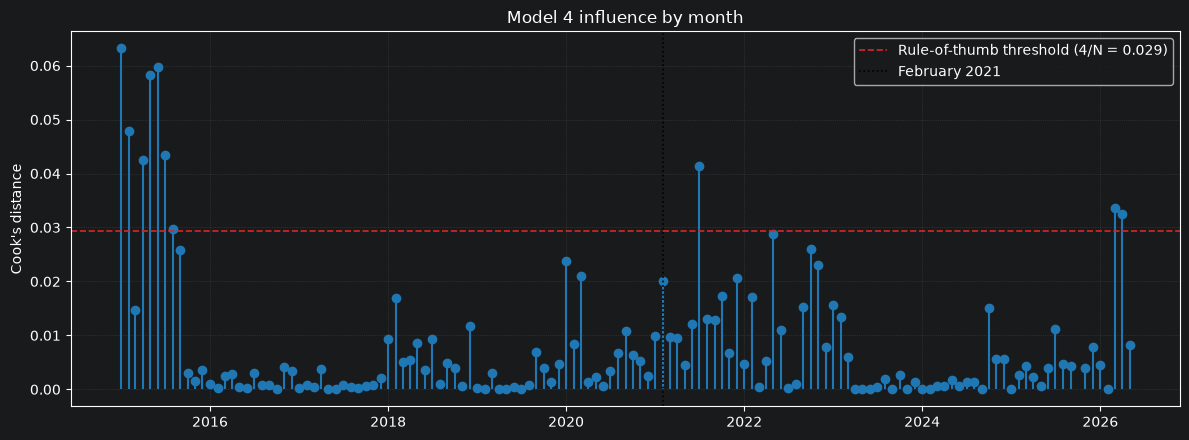

Influence table saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\baseline_model_4_influential_months.csv
Influence figure saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\figures\baseline_model_4_cooks_distance.png


In [18]:
INFLUENCE_TABLE_PATH = (
    TABLE_DIRECTORY
    / "baseline_model_4_influential_months.csv"
)

influential_months.to_csv(
    INFLUENCE_TABLE_PATH,
    index=False,
)

fig, ax = plt.subplots(
    figsize=(12, 4.5)
)

ax.stem(
    influence_table["period"],
    influence_table["cooks_d"],
    linefmt="tab:blue",
    markerfmt="o",
    basefmt=" ",
)

ax.axhline(
    COOKS_DISTANCE_THRESHOLD,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label=(
        "Rule-of-thumb threshold "
        f"(4/N = {COOKS_DISTANCE_THRESHOLD:.3f})"
    ),
)

ax.axvline(
    URI_MONTH,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="February 2021",
)

ax.set_title(
    "Model 4 influence by month"
)

ax.set_ylabel(
    "Cook's distance"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend()

fig.tight_layout()

INFLUENCE_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "baseline_model_4_cooks_distance.png"
)

fig.savefig(
    INFLUENCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Influence table saved to: "
    f"{INFLUENCE_TABLE_PATH}"
)

print(
    f"Influence figure saved to: "
    f"{INFLUENCE_FIGURE_PATH}"
)

## 4. Robustness checks

Three alternative specifications are estimated:

1. the preferred level model excluding February 2021;
2. the preferred level model using the one-month-lagged Henry Hub price;
3. a year-over-year change model.

The first specification examines sensitivity to Winter Storm Uri. The second allows for delayed fuel-cost pass-through. The third reduces concerns about common trends and recurring seasonal patterns.

All specifications continue to use HAC standard errors with a maximum lag length of 12 months.

In [19]:
def fit_hac_model(
    formula,
    data,
    max_lags=HAC_MAX_LAGS,
):
    return (
        smf.ols(
            formula=formula,
            data=data,
        )
        .fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": max_lags,
                "use_correction": True,
            },
        )
    )


uri_excluded_df = (
    model_df.loc[
        model_df["period"] != URI_MONTH
    ]
    .copy()
    .reset_index(drop=True)
)

uri_excluded_model = fit_hac_model(
    formula=MODEL_FORMULAS["Model 4"],
    data=uri_excluded_df,
)

print(
    "Baseline Model 4 observations: "
    f"{int(preferred_model.nobs)}"
)

print(
    "Excluding February 2021: "
    f"{int(uri_excluded_model.nobs)}"
)

print(
    "Henry Hub coefficient:"
)

print(
    "  Baseline: "
    f"{preferred_model.params['henry_hub_natural_gas_price']:.4f}"
)

print(
    "  Excluding February 2021: "
    f"{uri_excluded_model.params['henry_hub_natural_gas_price']:.4f}"
)

Baseline Model 4 observations: 136
Excluding February 2021: 135
Henry Hub coefficient:
  Baseline: 0.0517
  Excluding February 2021: 0.0482


In [20]:
lagged_analysis_df = analysis_df.copy()

lagged_analysis_df[
    "henry_hub_natural_gas_price_lag_1"
] = (
    lagged_analysis_df[
        "henry_hub_natural_gas_price"
    ]
    .shift(1)
)

LAGGED_ESTIMATION_VARIABLES = [
    OUTCOME_VARIABLE,
    "henry_hub_natural_gas_price_lag_1",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "month_of_year",
]

lagged_model_df = (
    lagged_analysis_df
    .dropna(
        subset=LAGGED_ESTIMATION_VARIABLES
    )
    .reset_index(drop=True)
)

LAGGED_GAS_FORMULA = (
    f"{OUTCOME_VARIABLE} "
    "~ henry_hub_natural_gas_price_lag_1 "
    "+ natural_gas_share_pp "
    "+ renewable_share_pp "
    "+ tx_heating_degree_days "
    "+ tx_cooling_degree_days "
    "+ time_trend "
    "+ C(month_of_year)"
)

lagged_gas_model = fit_hac_model(
    formula=LAGGED_GAS_FORMULA,
    data=lagged_model_df,
)

print(
    f"Lagged-price observations: "
    f"{int(lagged_gas_model.nobs)}"
)

print(
    "Lagged Henry Hub coefficient: "
    f"{lagged_gas_model.params[
        'henry_hub_natural_gas_price_lag_1'
    ]:.4f}"
)

print(
    "HAC p-value: "
    f"{lagged_gas_model.pvalues[
        'henry_hub_natural_gas_price_lag_1'
    ]:.4f}"
)

Lagged-price observations: 135
Lagged Henry Hub coefficient: 0.0550
HAC p-value: 0.2619


In [21]:
yoy_df = analysis_df.copy()

POSITIVE_LOG_VARIABLES = [
    OUTCOME_VARIABLE,
    "henry_hub_natural_gas_price",
]

nonpositive_values = (
    yoy_df[POSITIVE_LOG_VARIABLES]
    .le(0)
    .any()
)

if nonpositive_values.any():
    raise ValueError(
        "Log differences require positive values. "
        f"Problematic variables: "
        f"{nonpositive_values[
            nonpositive_values
        ].index.tolist()}"
    )

yoy_df[
    "residential_price_real_yoy_pct"
] = (
    100
    * (
        np.log(yoy_df[OUTCOME_VARIABLE])
        - np.log(
            yoy_df[OUTCOME_VARIABLE]
            .shift(12)
        )
    )
)

yoy_df[
    "henry_hub_price_yoy_pct"
] = (
    100
    * (
        np.log(
            yoy_df[
                "henry_hub_natural_gas_price"
            ]
        )
        - np.log(
            yoy_df[
                "henry_hub_natural_gas_price"
            ]
            .shift(12)
        )
    )
)

yoy_df[
    "natural_gas_share_yoy_pp"
] = (
    yoy_df["natural_gas_share_pp"]
    - yoy_df["natural_gas_share_pp"]
    .shift(12)
)

yoy_df[
    "renewable_share_yoy_pp"
] = (
    yoy_df["renewable_share_pp"]
    - yoy_df["renewable_share_pp"]
    .shift(12)
)

yoy_df[
    "heating_degree_days_yoy_change"
] = (
    yoy_df["tx_heating_degree_days"]
    - yoy_df["tx_heating_degree_days"]
    .shift(12)
)

yoy_df[
    "cooling_degree_days_yoy_change"
] = (
    yoy_df["tx_cooling_degree_days"]
    - yoy_df["tx_cooling_degree_days"]
    .shift(12)
)

YOY_MODEL_VARIABLES = [
    "residential_price_real_yoy_pct",
    "henry_hub_price_yoy_pct",
    "natural_gas_share_yoy_pp",
    "renewable_share_yoy_pp",
    "heating_degree_days_yoy_change",
    "cooling_degree_days_yoy_change",
]

yoy_model_df = (
    yoy_df
    .dropna(
        subset=YOY_MODEL_VARIABLES
    )
    .reset_index(drop=True)
)

print(
    f"Year-over-year model observations: "
    f"{len(yoy_model_df)}"
)

print(
    "Year-over-year estimation period: "
    f"{yoy_model_df['period'].min():%Y-%m} to "
    f"{yoy_model_df['period'].max():%Y-%m}"
)

yoy_model_df[
    [
        "period",
        *YOY_MODEL_VARIABLES,
    ]
].head()

Year-over-year model observations: 124
Year-over-year estimation period: 2016-01 to 2026-05


,period,residential_price_real_yoy_pct,henry_hub_price_yoy_pct,natural_gas_share_yoy_pp,renewable_share_yoy_pp,heating_degree_days_yoy_change,cooling_degree_days_yoy_change
0,2016-01-01,-6.684993,-27.109794,1.200772,4.470684,-71.0,5.0
1,2016-02-01,-6.417907,-36.617739,0.153649,6.752907,-164.0,24.0
2,2016-03-01,-4.140699,-49.215530,-1.559347,9.853660,-101.0,58.0
3,2016-04-01,-8.360687,-30.702504,-1.379436,1.918494,6.0,-19.0
4,2016-05-01,-9.201636,-39.499381,2.202333,2.311947,0.0,-18.0


In [22]:
YOY_MODEL_FORMULA = (
    "residential_price_real_yoy_pct "
    "~ henry_hub_price_yoy_pct "
    "+ natural_gas_share_yoy_pp "
    "+ renewable_share_yoy_pp "
    "+ heating_degree_days_yoy_change "
    "+ cooling_degree_days_yoy_change"
)

yoy_model = fit_hac_model(
    formula=YOY_MODEL_FORMULA,
    data=yoy_model_df,
)

print(
    f"Observations: {int(yoy_model.nobs)}"
)

print(
    f"R-squared: {yoy_model.rsquared:.4f}"
)

print(
    "Henry Hub year-over-year coefficient: "
    f"{yoy_model.params[
        'henry_hub_price_yoy_pct'
    ]:.4f}"
)

print(
    "HAC p-value: "
    f"{yoy_model.pvalues[
        'henry_hub_price_yoy_pct'
    ]:.4f}"
)

Observations: 124
R-squared: 0.1917
Henry Hub year-over-year coefficient: 0.0264
HAC p-value: 0.0063


In [23]:
ROBUSTNESS_SPECIFICATIONS = {
    "Baseline Model 4": {
        "result": preferred_model,
        "gas_variable": (
            "henry_hub_natural_gas_price"
        ),
        "effect_scale": (
            "Cents/kWh per $/MMBtu"
        ),
    },
    "Excluding February 2021": {
        "result": uri_excluded_model,
        "gas_variable": (
            "henry_hub_natural_gas_price"
        ),
        "effect_scale": (
            "Cents/kWh per $/MMBtu"
        ),
    },
    "Lagged Henry Hub price": {
        "result": lagged_gas_model,
        "gas_variable": (
            "henry_hub_natural_gas_price_lag_1"
        ),
        "effect_scale": (
            "Cents/kWh per lagged $/MMBtu"
        ),
    },
    "Year-over-year changes": {
        "result": yoy_model,
        "gas_variable": (
            "henry_hub_price_yoy_pct"
        ),
        "effect_scale": (
            "Approximate year-over-year elasticity"
        ),
    },
}

key_effect_rows = []

for specification, settings in (
    ROBUSTNESS_SPECIFICATIONS.items()
):
    result = settings["result"]
    variable = settings["gas_variable"]

    confidence_interval = (
        result.conf_int()
        .loc[variable]
    )

    key_effect_rows.append(
        {
            "specification": specification,
            "gas_variable": variable,
            "effect_scale": settings[
                "effect_scale"
            ],
            "coefficient": (
                result.params[variable]
            ),
            "hac_standard_error": (
                result.bse[variable]
            ),
            "p_value": (
                result.pvalues[variable]
            ),
            "confidence_interval_95_lower": (
                confidence_interval.iloc[0]
            ),
            "confidence_interval_95_upper": (
                confidence_interval.iloc[1]
            ),
            "observations": int(result.nobs),
            "r_squared": result.rsquared,
            "adjusted_r_squared": (
                result.rsquared_adj
            ),
        }
    )

robustness_key_effects = (
    pd.DataFrame(key_effect_rows)
    .round(4)
)

ROBUSTNESS_KEY_EFFECTS_PATH = (
    TABLE_DIRECTORY
    / "robustness_henry_hub_effects.csv"
)

robustness_key_effects.to_csv(
    ROBUSTNESS_KEY_EFFECTS_PATH,
    index=False,
)

robustness_key_effects

,specification,gas_variable,effect_scale,coefficient,hac_standard_error,p_value,confidence_interval_95_lower,confidence_interval_95_upper,observations,r_squared,adjusted_r_squared
0,Baseline Model 4,henry_hub_natural_gas_price,Cents/kWh per $/MMBtu,0.0517,0.0487,0.2883,-0.0437,0.1471,136,0.3107,0.2114
1,Excluding February 2021,henry_hub_natural_gas_price,Cents/kWh per $/MMBtu,0.0482,0.0488,0.3236,-0.0475,0.1439,135,0.3149,0.2153
2,Lagged Henry Hub price,henry_hub_natural_gas_price_lag_1,Cents/kWh per lagged $/MMBtu,0.0550,0.0490,0.2619,-0.0411,0.1510,135,0.3503,0.2559
3,Year-over-year changes,henry_hub_price_yoy_pct,Approximate year-over-year elasticity,0.0264,0.0097,0.0063,0.0075,0.0454,124,0.1917,0.1574


In [24]:
robustness_diagnostic_rows = []

for specification, settings in (
    ROBUSTNESS_SPECIFICATIONS.items()
):
    result = settings["result"]

    ljung_box_lag_12 = acorr_ljungbox(
        result.resid,
        lags=[12],
        return_df=True,
    )

    robustness_diagnostic_rows.append(
        {
            "specification": specification,
            "observations": int(result.nobs),
            "r_squared": result.rsquared,
            "adjusted_r_squared": (
                result.rsquared_adj
            ),
            "durbin_watson": (
                durbin_watson(result.resid)
            ),
            "ljung_box_p_value_lag_12": (
                ljung_box_lag_12[
                    "lb_pvalue"
                ].iloc[0]
            ),
        }
    )

robustness_diagnostics = (
    pd.DataFrame(
        robustness_diagnostic_rows
    )
    .round(4)
)

ROBUSTNESS_DIAGNOSTICS_PATH = (
    TABLE_DIRECTORY
    / "robustness_model_diagnostics.csv"
)

robustness_diagnostics.to_csv(
    ROBUSTNESS_DIAGNOSTICS_PATH,
    index=False,
)

display(robustness_key_effects)
display(robustness_diagnostics)

print(
    f"Key effects saved to: "
    f"{ROBUSTNESS_KEY_EFFECTS_PATH}"
)

print(
    f"Diagnostics saved to: "
    f"{ROBUSTNESS_DIAGNOSTICS_PATH}"
)

,specification,gas_variable,effect_scale,coefficient,hac_standard_error,p_value,confidence_interval_95_lower,confidence_interval_95_upper,observations,r_squared,adjusted_r_squared
0,Baseline Model 4,henry_hub_natural_gas_price,Cents/kWh per $/MMBtu,0.0517,0.0487,0.2883,-0.0437,0.1471,136,0.3107,0.2114
1,Excluding February 2021,henry_hub_natural_gas_price,Cents/kWh per $/MMBtu,0.0482,0.0488,0.3236,-0.0475,0.1439,135,0.3149,0.2153
2,Lagged Henry Hub price,henry_hub_natural_gas_price_lag_1,Cents/kWh per lagged $/MMBtu,0.0550,0.0490,0.2619,-0.0411,0.1510,135,0.3503,0.2559
3,Year-over-year changes,henry_hub_price_yoy_pct,Approximate year-over-year elasticity,0.0264,0.0097,0.0063,0.0075,0.0454,124,0.1917,0.1574


,specification,observations,r_squared,adjusted_r_squared,durbin_watson,ljung_box_p_value_lag_12
0,Baseline Model 4,136,0.3107,0.2114,0.3780,0.0
1,Excluding February 2021,135,0.3149,0.2153,0.3018,0.0
2,Lagged Henry Hub price,135,0.3503,0.2559,0.4756,0.0
3,Year-over-year changes,124,0.1917,0.1574,0.5614,0.0


Key effects saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\robustness_henry_hub_effects.csv
Diagnostics saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\robustness_model_diagnostics.csv


## 5. Dynamic specification

The static specifications exhibit strong positive residual autocorrelation. HAC standard errors improve inference under serial correlation but do not model the persistence of residential electricity prices directly.

An autoregressive distributed-lag specification is therefore estimated by adding the one-month-lagged dependent variable. The lag is constructed on the complete monthly sequence before observations with missing values are removed.

The dynamic specification remains an association model and should not be interpreted causally.

In [25]:
LAGGED_OUTCOME_VARIABLE = (
    "residential_price_real_2025_01_lag_1"
)

dynamic_analysis_df = analysis_df.copy()

# Construct the lag before dropping missing observations.
dynamic_analysis_df[
    LAGGED_OUTCOME_VARIABLE
] = (
    dynamic_analysis_df[
        OUTCOME_VARIABLE
    ]
    .shift(1)
)

DYNAMIC_ESTIMATION_VARIABLES = [
    OUTCOME_VARIABLE,
    LAGGED_OUTCOME_VARIABLE,
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "month_of_year",
]

dynamic_model_df = (
    dynamic_analysis_df
    .dropna(
        subset=DYNAMIC_ESTIMATION_VARIABLES
    )
    .reset_index(drop=True)
)

print(
    f"Dynamic-model observations: "
    f"{len(dynamic_model_df)}"
)

print(
    "Dynamic-model period: "
    f"{dynamic_model_df['period'].min():%Y-%m} to "
    f"{dynamic_model_df['period'].max():%Y-%m}"
)

Dynamic-model observations: 134
Dynamic-model period: 2015-02 to 2026-05


In [26]:
DYNAMIC_MODEL_FORMULA = (
    f"{OUTCOME_VARIABLE} "
    f"~ {LAGGED_OUTCOME_VARIABLE} "
    "+ henry_hub_natural_gas_price "
    "+ natural_gas_share_pp "
    "+ renewable_share_pp "
    "+ tx_heating_degree_days "
    "+ tx_cooling_degree_days "
    "+ time_trend "
    "+ C(month_of_year)"
)

dynamic_model = fit_hac_model(
    formula=DYNAMIC_MODEL_FORMULA,
    data=dynamic_model_df,
)

static_same_sample_model = fit_hac_model(
    formula=MODEL_FORMULAS["Model 4"],
    data=dynamic_model_df,
)

print(
    "Lagged dependent-variable coefficient: "
    f"{dynamic_model.params[
        LAGGED_OUTCOME_VARIABLE
    ]:.4f}"
)

print(
    "HAC p-value: "
    f"{dynamic_model.pvalues[
        LAGGED_OUTCOME_VARIABLE
    ]:.4f}"
)

print(
    "Henry Hub coefficient: "
    f"{dynamic_model.params[
        'henry_hub_natural_gas_price'
    ]:.4f}"
)

print(
    "Henry Hub HAC p-value: "
    f"{dynamic_model.pvalues[
        'henry_hub_natural_gas_price'
    ]:.4f}"
)

Lagged dependent-variable coefficient: 0.8083
HAC p-value: 0.0000
Henry Hub coefficient: 0.0487
Henry Hub HAC p-value: 0.0015


In [27]:
dynamic_comparison_rows = []

COMPARISON_MODELS = {
    "Static Model 4, matched sample": (
        static_same_sample_model
    ),
    "Dynamic Model": dynamic_model,
}

for specification, result in (
    COMPARISON_MODELS.items()
):
    ljung_box_12 = acorr_ljungbox(
        result.resid,
        lags=[12],
        return_df=True,
    )

    dynamic_comparison_rows.append(
        {
            "specification": specification,
            "observations": int(result.nobs),
            "r_squared": result.rsquared,
            "adjusted_r_squared": (
                result.rsquared_adj
            ),
            "aic": result.aic,
            "bic": result.bic,
            "durbin_watson": (
                durbin_watson(result.resid)
            ),
            "ljung_box_p_value_lag_12": (
                ljung_box_12[
                    "lb_pvalue"
                ].iloc[0]
            ),
        }
    )

dynamic_model_comparison = (
    pd.DataFrame(dynamic_comparison_rows)
    .round(4)
)

dynamic_ljung_box = (
    acorr_ljungbox(
        dynamic_model.resid,
        lags=DIAGNOSTIC_LAGS,
        return_df=True,
    )
    .reset_index()
    .rename(
        columns={
            "index": "lag",
            "lb_stat": "ljung_box_statistic",
            "lb_pvalue": "p_value",
        }
    )
    .round(4)
)

display(dynamic_model_comparison)
display(dynamic_ljung_box)

,specification,observations,r_squared,adjusted_r_squared,aic,bic,durbin_watson,ljung_box_p_value_lag_12
0,"Static Model 4, matched sample",134,0.3394,0.2425,211.5929,263.7540,0.4159,0.0000
1,Dynamic Model,134,0.8226,0.7949,37.3857,92.4446,2.4982,0.0089


,lag,ljung_box_statistic,p_value
0,1,8.8547,0.0029
1,6,14.3698,0.0258
2,12,26.5577,0.0089


In [28]:
dynamic_model_comparison.to_csv(
    TABLE_DIRECTORY
    / "dynamic_model_comparison.csv",
    index=False,
)

dynamic_ljung_box.to_csv(
    TABLE_DIRECTORY
    / "dynamic_ljung_box_tests.csv",
    index=False,
)

### Second-order dynamic specification

The first-order dynamic model substantially improves fit and removes the strong positive residual persistence found in the static model. However, its Durbin–Watson statistic exceeds two and the Ljung–Box tests remain significant.

A second lag of the dependent variable is therefore added. The first- and second-order dynamic models are re-estimated on the same sample to ensure comparability.

In [29]:
OUTCOME_LAG_1 = (
    "residential_price_real_2025_01_lag_1"
)

OUTCOME_LAG_2 = (
    "residential_price_real_2025_01_lag_2"
)

dynamic_order_df = analysis_df.copy()

dynamic_order_df[OUTCOME_LAG_1] = (
    dynamic_order_df[OUTCOME_VARIABLE].shift(1)
)

dynamic_order_df[OUTCOME_LAG_2] = (
    dynamic_order_df[OUTCOME_VARIABLE].shift(2)
)

DYNAMIC_ORDER_VARIABLES = [
    OUTCOME_VARIABLE,
    OUTCOME_LAG_1,
    OUTCOME_LAG_2,
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "month_of_year",
]

dynamic_order_df = (
    dynamic_order_df
    .dropna(subset=DYNAMIC_ORDER_VARIABLES)
    .reset_index(drop=True)
)

print(f"Matched observations: {len(dynamic_order_df)}")
print(
    "Estimation period: "
    f"{dynamic_order_df['period'].min():%Y-%m} to "
    f"{dynamic_order_df['period'].max():%Y-%m}"
)

Matched observations: 132
Estimation period: 2015-03 to 2026-05


In [30]:
STATIC_MATCHED_FORMULA = MODEL_FORMULAS["Model 4"]

AR1_MATCHED_FORMULA = (
    f"{OUTCOME_VARIABLE} "
    f"~ {OUTCOME_LAG_1} "
    "+ henry_hub_natural_gas_price "
    "+ natural_gas_share_pp "
    "+ renewable_share_pp "
    "+ tx_heating_degree_days "
    "+ tx_cooling_degree_days "
    "+ time_trend "
    "+ C(month_of_year)"
)

AR2_FORMULA = (
    f"{OUTCOME_VARIABLE} "
    f"~ {OUTCOME_LAG_1} "
    f"+ {OUTCOME_LAG_2} "
    "+ henry_hub_natural_gas_price "
    "+ natural_gas_share_pp "
    "+ renewable_share_pp "
    "+ tx_heating_degree_days "
    "+ tx_cooling_degree_days "
    "+ time_trend "
    "+ C(month_of_year)"
)

static_order_matched_model = fit_hac_model(
    STATIC_MATCHED_FORMULA,
    dynamic_order_df,
)

ar1_order_matched_model = fit_hac_model(
    AR1_MATCHED_FORMULA,
    dynamic_order_df,
)

ar2_model = fit_hac_model(
    AR2_FORMULA,
    dynamic_order_df,
)

KEY_DYNAMIC_VARIABLES = [
    OUTCOME_LAG_1,
    OUTCOME_LAG_2,
    "henry_hub_natural_gas_price",
]

for variable in KEY_DYNAMIC_VARIABLES:
    if variable in ar2_model.params.index:
        print(
            f"{variable}: "
            f"coefficient={ar2_model.params[variable]:.4f}, "
            f"p-value={ar2_model.pvalues[variable]:.4f}"
        )

residential_price_real_2025_01_lag_1: coefficient=0.5543, p-value=0.0000
residential_price_real_2025_01_lag_2: coefficient=0.2893, p-value=0.0005
henry_hub_natural_gas_price: coefficient=0.0559, p-value=0.0012


In [31]:
DYNAMIC_ORDER_MODELS = {
    "Static matched model": static_order_matched_model,
    "AR(1) matched model": ar1_order_matched_model,
    "AR(2) model": ar2_model,
}

comparison_rows = []

for specification, result in DYNAMIC_ORDER_MODELS.items():
    ljung_box = acorr_ljungbox(
        result.resid,
        lags=DIAGNOSTIC_LAGS,
        return_df=True,
    )

    comparison_rows.append(
        {
            "specification": specification,
            "observations": int(result.nobs),
            "r_squared": result.rsquared,
            "adjusted_r_squared": result.rsquared_adj,
            "aic": result.aic,
            "bic": result.bic,
            "durbin_watson": durbin_watson(result.resid),
            "ljung_box_p_lag_1": (
                ljung_box.loc[1, "lb_pvalue"]
            ),
            "ljung_box_p_lag_6": (
                ljung_box.loc[6, "lb_pvalue"]
            ),
            "ljung_box_p_lag_12": (
                ljung_box.loc[12, "lb_pvalue"]
            ),
        }
    )

dynamic_order_comparison = (
    pd.DataFrame(comparison_rows).round(4)
)

dynamic_order_comparison

,specification,observations,r_squared,adjusted_r_squared,aic,bic,durbin_watson,ljung_box_p_lag_1,ljung_box_p_lag_6,ljung_box_p_lag_12
0,Static matched model,132,0.3624,0.2673,202.1607,254.0512,0.4332,0.0000,0.0000,0.0000
1,AR(1) matched model,132,0.8182,0.7893,38.5031,93.2763,2.4761,0.0045,0.0605,0.0842
2,AR(2) model,132,0.8351,0.8072,27.6031,85.2591,2.1750,0.2662,0.0364,0.0324


In [32]:
DYNAMIC_ORDER_COMPARISON_PATH = (
    TABLE_DIRECTORY
    / "dynamic_order_comparison.csv"
)

dynamic_order_comparison.to_csv(
    DYNAMIC_ORDER_COMPARISON_PATH,
    index=False,
)

print(
    f"Dynamic-order comparison saved to: "
    f"{DYNAMIC_ORDER_COMPARISON_PATH}"
)

Dynamic-order comparison saved to: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor\reports\tables\dynamic_order_comparison.csv


### Residual diagnostics for the AR(2) model

The AR(2) specification substantially improves fit and removes most of the residual persistence found in the static and AR(1) models.

The lag-12 Ljung–Box test remains marginally significant. Because this cumulative test does not identify the individual lag responsible for the rejection, the residual autocorrelation and partial autocorrelation functions are examined. Breusch–Godfrey tests are also reported because the model contains lagged dependent variables.

In [33]:
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
)
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf


# Conventional covariance is sufficient for residual
# diagnostic tests. The fitted values and residuals are
# identical to those of the HAC model.
ar2_diagnostic_fit = smf.ols(
    formula=AR2_FORMULA,
    data=dynamic_order_df,
).fit()

BG_TEST_LAGS = [1, 6, 12]

bg_rows = []

for lag in BG_TEST_LAGS:
    (
        lm_statistic,
        lm_p_value,
        f_statistic,
        f_p_value,
    ) = acorr_breusch_godfrey(
        ar2_diagnostic_fit,
        nlags=lag,
    )

    bg_rows.append(
        {
            "maximum_lag": lag,
            "lm_statistic": lm_statistic,
            "lm_p_value": lm_p_value,
            "f_statistic": f_statistic,
            "f_p_value": f_p_value,
        }
    )

ar2_breusch_godfrey = (
    pd.DataFrame(bg_rows)
    .round(4)
)

ar2_breusch_godfrey

,maximum_lag,lm_statistic,lm_p_value,f_statistic,f_p_value
0,1,7.0395,0.0080,6.2530,0.0139
1,6,19.7187,0.0031,3.1026,0.0077
2,12,26.3647,0.0095,2.0799,0.0248


In [34]:
RESIDUAL_ACF_MAX_LAG = 24

ar2_residuals = np.asarray(
    ar2_diagnostic_fit.resid
)

acf_values = acf(
    ar2_residuals,
    nlags=RESIDUAL_ACF_MAX_LAG,
    fft=False,
)

pacf_values = pacf(
    ar2_residuals,
    nlags=RESIDUAL_ACF_MAX_LAG,
    method="ywm",
)

approximate_bound = (
    1.96 / np.sqrt(len(ar2_residuals))
)

ar2_residual_correlation = pd.DataFrame(
    {
        "lag": range(
            1,
            RESIDUAL_ACF_MAX_LAG + 1,
        ),
        "acf": acf_values[1:],
        "pacf": pacf_values[1:],
    }
)

ar2_residual_correlation[
    "acf_outside_approximate_95_bound"
] = (
    ar2_residual_correlation["acf"].abs()
    > approximate_bound
)

ar2_residual_correlation = (
    ar2_residual_correlation.round(4)
)

display(ar2_residual_correlation)
display(
    ar2_residual_correlation.loc[
        ar2_residual_correlation[
            "acf_outside_approximate_95_bound"
        ]
    ]
)

,lag,acf,pacf,acf_outside_approximate_95_bound
0,1,-0.0957,-0.0957,False
1,2,-0.2756,-0.2874,True
2,3,0.0717,0.0112,False
3,4,0.0394,-0.0328,False
4,5,-0.0547,-0.0330,False
5,6,-0.0621,-0.0773,False
6,7,0.0622,0.0262,False
7,8,-0.0144,-0.0427,False
8,9,-0.0147,0.0089,False
9,10,0.1562,0.1508,False


,lag,acf,pacf,acf_outside_approximate_95_bound
1,2,-0.2756,-0.2874,True
15,16,-0.1957,-0.1370,True
20,21,0.1778,0.2148,True


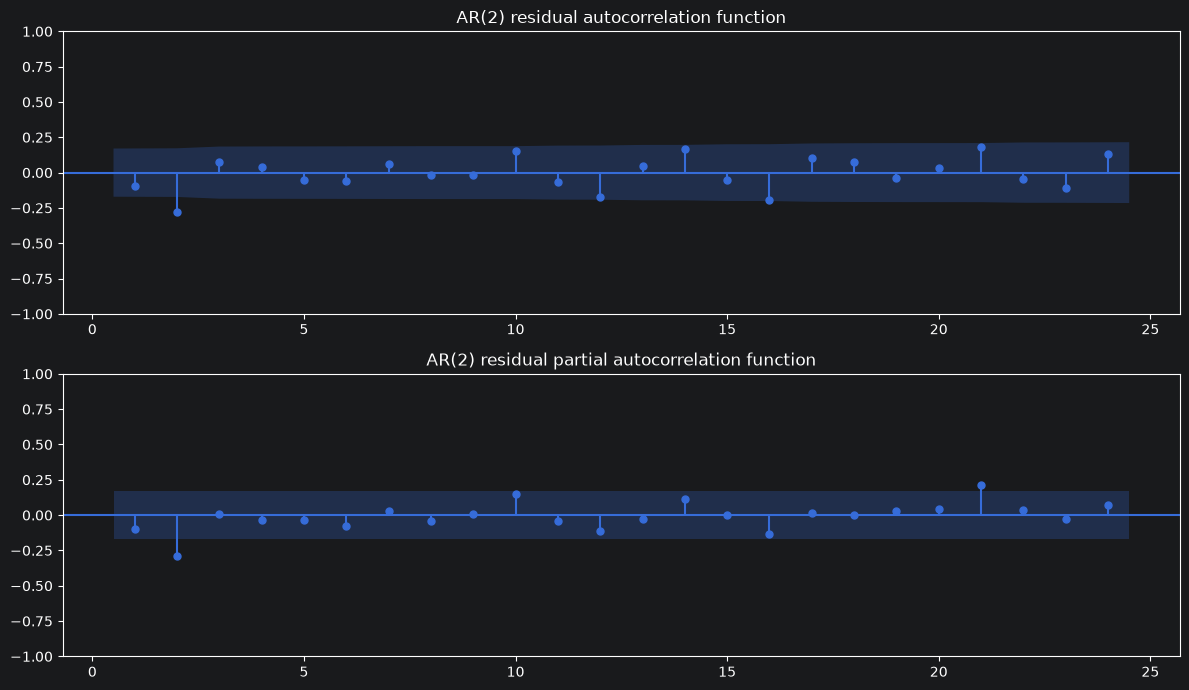

In [35]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
)

plot_acf(
    ar2_residuals,
    lags=RESIDUAL_ACF_MAX_LAG,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "AR(2) residual autocorrelation function"
)

plot_pacf(
    ar2_residuals,
    lags=RESIDUAL_ACF_MAX_LAG,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "AR(2) residual partial autocorrelation function"
)

fig.tight_layout()

AR2_RESIDUAL_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "ar2_residual_acf_pacf.png"
)

fig.savefig(
    AR2_RESIDUAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [36]:
ar2_breusch_godfrey.to_csv(
    TABLE_DIRECTORY
    / "ar2_breusch_godfrey_tests.csv",
    index=False,
)

ar2_residual_correlation.to_csv(
    TABLE_DIRECTORY
    / "ar2_residual_correlations.csv",
    index=False,
)

### Selection of the short-run dynamic order

The AR(2) residuals continue to reject the null hypothesis of no serial correlation in the Breusch–Godfrey tests. The most pronounced residual ACF and PACF spike occurs at lag two, while the longer-lag spikes are comparatively modest.

AR(2), AR(3), and AR(4) specifications are therefore compared on a common estimation sample. A seasonal lag is not introduced at this stage because the significant lag-12 Breusch–Godfrey test is cumulative and may reflect remaining short-run serial correlation.

In [37]:
CANDIDATE_AR_ORDERS = [2, 3, 4]
MAX_CANDIDATE_AR_ORDER = max(
    CANDIDATE_AR_ORDERS
)

ar_order_selection_df = analysis_df.copy()

OUTCOME_LAG_NAMES = {}

for lag in range(
    1,
    MAX_CANDIDATE_AR_ORDER + 1,
):
    lag_name = (
        f"{OUTCOME_VARIABLE}_lag_{lag}"
    )

    OUTCOME_LAG_NAMES[lag] = lag_name

    ar_order_selection_df[lag_name] = (
        ar_order_selection_df[
            OUTCOME_VARIABLE
        ].shift(lag)
    )

AR_ORDER_SELECTION_VARIABLES = [
    OUTCOME_VARIABLE,
    *OUTCOME_LAG_NAMES.values(),
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "month_of_year",
]

ar_order_selection_df = (
    ar_order_selection_df
    .dropna(
        subset=AR_ORDER_SELECTION_VARIABLES
    )
    .reset_index(drop=True)
)

print(
    "Matched observations: "
    f"{len(ar_order_selection_df)}"
)

print(
    "Matched estimation period: "
    f"{ar_order_selection_df['period'].min():%Y-%m} "
    "to "
    f"{ar_order_selection_df['period'].max():%Y-%m}"
)

Matched observations: 128
Matched estimation period: 2015-05 to 2026-05


In [38]:
DYNAMIC_CONTROL_TERMS = [
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
    "time_trend",
    "C(month_of_year)",
]


def build_ar_formula(order):
    lag_terms = [
        OUTCOME_LAG_NAMES[lag]
        for lag in range(1, order + 1)
    ]

    right_hand_side = " + ".join(
        [
            *lag_terms,
            *DYNAMIC_CONTROL_TERMS,
        ]
    )

    return (
        f"{OUTCOME_VARIABLE} "
        f"~ {right_hand_side}"
    )


AR_CANDIDATE_FORMULAS = {
    order: build_ar_formula(order)
    for order in CANDIDATE_AR_ORDERS
}

AR_CANDIDATE_FORMULAS

{2: 'residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days + time_trend + C(month_of_year)',
 3: 'residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + residential_price_real_2025_01_lag_3 + henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days + time_trend + C(month_of_year)',
 4: 'residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + residential_price_real_2025_01_lag_3 + residential_price_real_2025_01_lag_4 + henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days + time_trend + C(month_of_year)'}

In [39]:
ar_candidate_models = {}
ar_candidate_diagnostic_fits = {}

for order, formula in (
    AR_CANDIDATE_FORMULAS.items()
):
    ar_candidate_models[order] = (
        fit_hac_model(
            formula=formula,
            data=ar_order_selection_df,
        )
    )

    ar_candidate_diagnostic_fits[order] = (
        smf.ols(
            formula=formula,
            data=ar_order_selection_df,
        ).fit()
    )

In [40]:
AR_ORDER_BG_LAGS = [1, 6, 12]

ar_order_comparison_rows = []

for order in CANDIDATE_AR_ORDERS:
    result = ar_candidate_models[order]
    diagnostic_fit = (
        ar_candidate_diagnostic_fits[order]
    )

    bg_p_values = {}

    for test_lag in AR_ORDER_BG_LAGS:
        (
            lm_statistic,
            lm_p_value,
            f_statistic,
            f_p_value,
        ) = acorr_breusch_godfrey(
            diagnostic_fit,
            nlags=test_lag,
        )

        bg_p_values[test_lag] = lm_p_value

    ar_coefficients = np.array(
        [
            result.params[
                OUTCOME_LAG_NAMES[lag]
            ]
            for lag in range(1, order + 1)
        ]
    )

    # Roots of:
    # 1 - phi_1*z - ... - phi_p*z^p = 0
    ar_roots = np.roots(
        np.r_[
            -ar_coefficients[::-1],
            1.0,
        ]
    )

    minimum_root_modulus = (
        np.abs(ar_roots).min()
    )

    ar_order_comparison_rows.append(
        {
            "ar_order": order,
            "observations": int(result.nobs),
            "adjusted_r_squared": (
                result.rsquared_adj
            ),
            "aic": result.aic,
            "bic": result.bic,
            "durbin_watson": (
                durbin_watson(result.resid)
            ),
            "bg_lm_p_value_lag_1": (
                bg_p_values[1]
            ),
            "bg_lm_p_value_lag_6": (
                bg_p_values[6]
            ),
            "bg_lm_p_value_lag_12": (
                bg_p_values[12]
            ),
            "sum_of_ar_coefficients": (
                ar_coefficients.sum()
            ),
            "minimum_ar_root_modulus": (
                minimum_root_modulus
            ),
            "stationary_ar_dynamics": (
                minimum_root_modulus > 1
            ),
        }
    )

ar_order_candidate_comparison = (
    pd.DataFrame(ar_order_comparison_rows)
    .round(4)
)

ar_order_candidate_comparison

,ar_order,observations,adjusted_r_squared,aic,bic,durbin_watson,bg_lm_p_value_lag_1,bg_lm_p_value_lag_6,bg_lm_p_value_lag_12,sum_of_ar_coefficients,minimum_ar_root_modulus,stationary_ar_dynamics
0,2,128,0.8097,19.1075,76.1481,2.1596,0.0275,0.0816,0.1702,0.8582,1.1200,True
1,3,128,0.8273,7.5149,67.4076,1.9857,0.9321,0.5486,0.6149,0.8877,1.0680,True
2,4,128,0.8258,9.4414,72.1861,1.9706,0.9163,0.4931,0.6093,0.8890,1.0655,True


In [41]:
ar_order_effect_rows = []

for order in CANDIDATE_AR_ORDERS:
    result = ar_candidate_models[order]

    reported_variables = [
        *[
            OUTCOME_LAG_NAMES[lag]
            for lag in range(1, order + 1)
        ],
        "henry_hub_natural_gas_price",
    ]

    for variable in reported_variables:
        ar_order_effect_rows.append(
            {
                "ar_order": order,
                "variable": variable,
                "coefficient": (
                    result.params[variable]
                ),
                "hac_standard_error": (
                    result.bse[variable]
                ),
                "p_value": (
                    result.pvalues[variable]
                ),
            }
        )

ar_order_key_coefficients = (
    pd.DataFrame(ar_order_effect_rows)
    .round(4)
)

display(ar_order_candidate_comparison)
display(ar_order_key_coefficients)

,ar_order,observations,adjusted_r_squared,aic,bic,durbin_watson,bg_lm_p_value_lag_1,bg_lm_p_value_lag_6,bg_lm_p_value_lag_12,sum_of_ar_coefficients,minimum_ar_root_modulus,stationary_ar_dynamics
0,2,128,0.8097,19.1075,76.1481,2.1596,0.0275,0.0816,0.1702,0.8582,1.1200,True
1,3,128,0.8273,7.5149,67.4076,1.9857,0.9321,0.5486,0.6149,0.8877,1.0680,True
2,4,128,0.8258,9.4414,72.1861,1.9706,0.9163,0.4931,0.6093,0.8890,1.0655,True


,ar_order,variable,coefficient,hac_standard_error,p_value
0,2,residential_price_real_2025_01_lag_1,0.5699,0.0974,0.0000
1,2,residential_price_real_2025_01_lag_2,0.2883,0.1006,0.0042
2,2,henry_hub_natural_gas_price,0.0586,0.0178,0.0010
3,3,residential_price_real_2025_01_lag_1,0.4832,0.1236,0.0001
4,3,residential_price_real_2025_01_lag_2,0.1143,0.1063,0.2823
5,3,residential_price_real_2025_01_lag_3,0.2902,0.0676,0.0000
6,3,henry_hub_natural_gas_price,0.0740,0.0208,0.0004
7,4,residential_price_real_2025_01_lag_1,0.4783,0.1336,0.0003
8,4,residential_price_real_2025_01_lag_2,0.1103,0.0980,0.2601
9,4,residential_price_real_2025_01_lag_3,0.2787,0.0631,0.0000


In [42]:
ar_order_candidate_comparison.to_csv(
    TABLE_DIRECTORY
    / "ar_order_candidate_comparison.csv",
    index=False,
)

ar_order_key_coefficients.to_csv(
    TABLE_DIRECTORY
    / "ar_order_key_coefficients.csv",
    index=False,
)

### Preferred dynamic specification

The AR(3) specification is selected as the preferred dynamic model. It has the lowest AIC and BIC among the stable candidate models, the highest adjusted R-squared, and a Durbin–Watson statistic close to two.

The Breusch–Godfrey tests at maximum lags 1, 6, and 12 do not reject the null hypothesis of no remaining serial correlation. Adding a fourth lag does not improve the information criteria, and its coefficient is statistically insignificant.

Although the second lag is individually insignificant, it is retained to preserve the hierarchical structure of the third-order autoregressive specification.

In [43]:
PREFERRED_AR_ORDER = 3

preferred_dynamic_model = (
    ar_candidate_models[PREFERRED_AR_ORDER]
)

preferred_dynamic_diagnostic_fit = (
    ar_candidate_diagnostic_fits[
        PREFERRED_AR_ORDER
    ]
)

preferred_dynamic_residuals = np.asarray(
    preferred_dynamic_diagnostic_fit.resid
)

FINAL_RESIDUAL_MAX_LAG = 24

final_acf_values = acf(
    preferred_dynamic_residuals,
    nlags=FINAL_RESIDUAL_MAX_LAG,
    fft=False,
)

final_pacf_values = pacf(
    preferred_dynamic_residuals,
    nlags=FINAL_RESIDUAL_MAX_LAG,
    method="ywm",
)

final_approximate_bound = (
    1.96
    / np.sqrt(len(preferred_dynamic_residuals))
)

preferred_dynamic_residual_correlations = (
    pd.DataFrame(
        {
            "lag": range(
                1,
                FINAL_RESIDUAL_MAX_LAG + 1,
            ),
            "acf": final_acf_values[1:],
            "pacf": final_pacf_values[1:],
        }
    )
)

preferred_dynamic_residual_correlations[
    "acf_outside_approximate_95_bound"
] = (
    preferred_dynamic_residual_correlations[
        "acf"
    ].abs()
    > final_approximate_bound
)

preferred_dynamic_residual_correlations = (
    preferred_dynamic_residual_correlations
    .round(4)
)

display(
    preferred_dynamic_residual_correlations
)

display(
    preferred_dynamic_residual_correlations.loc[
        preferred_dynamic_residual_correlations[
            "acf_outside_approximate_95_bound"
        ]
    ]
)

,lag,acf,pacf,acf_outside_approximate_95_bound
0,1,-0.0037,-0.0037,False
1,2,0.0215,0.0215,False
2,3,-0.0794,-0.0793,False
3,4,0.0048,0.0039,False
4,5,-0.1053,-0.1026,False
5,6,-0.0544,-0.0623,False
6,7,0.0363,0.0409,False
7,8,-0.0413,-0.0569,False
8,9,-0.1059,-0.1189,False
9,10,0.0976,0.0977,False


,lag,acf,pacf,acf_outside_approximate_95_bound
15,16,-0.183,-0.1578,True


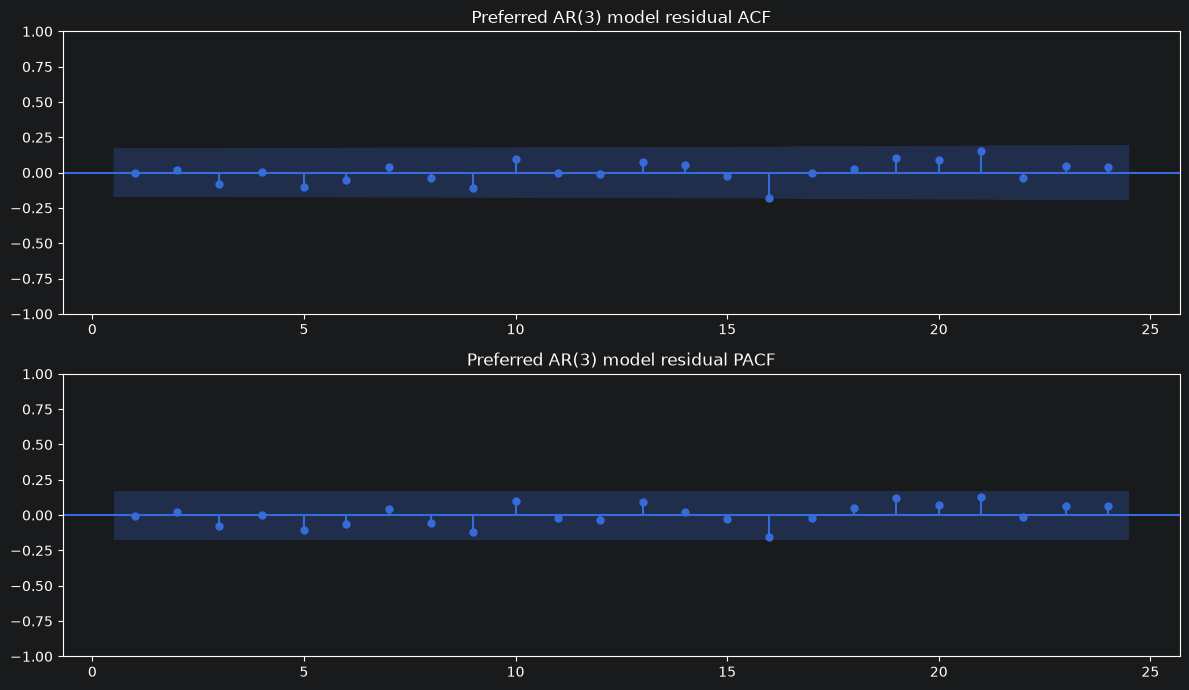

In [44]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
)

plot_acf(
    preferred_dynamic_residuals,
    lags=FINAL_RESIDUAL_MAX_LAG,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "Preferred AR(3) model residual ACF"
)

plot_pacf(
    preferred_dynamic_residuals,
    lags=FINAL_RESIDUAL_MAX_LAG,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "Preferred AR(3) model residual PACF"
)

fig.tight_layout()

PREFERRED_DYNAMIC_RESIDUAL_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "preferred_ar3_residual_acf_pacf.png"
)

fig.savefig(
    PREFERRED_DYNAMIC_RESIDUAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [45]:
preferred_dynamic_residual_correlations.to_csv(
    TABLE_DIRECTORY
    / "preferred_ar3_residual_correlations.csv",
    index=False,
)

## 6. Preferred model results

The AR(3) specification is retained as the preferred model. It provides the best combination of model fit, parsimony, dynamic stability, and residual diagnostics among the candidate specifications.

The residual ACF contains one isolated value outside the approximate 95% confidence bounds at lag 16. This isolated spike is not accompanied by a corresponding PACF spike, a continuous residual pattern, or evidence of seasonal autocorrelation at lag 12. With 24 residual correlations examined, an occasional value outside pointwise 95% bounds may occur by chance.

Together with the nonsignificant Breusch–Godfrey tests and a Durbin–Watson statistic close to two, the residual evidence does not justify adding further short-run or seasonal lags.

In [46]:
preferred_model_confidence_intervals = (
    preferred_dynamic_model.conf_int()
)

preferred_model_results = pd.DataFrame(
    {
        "variable": (
            preferred_dynamic_model.params.index
        ),
        "coefficient": (
            preferred_dynamic_model.params.values
        ),
        "hac_standard_error": (
            preferred_dynamic_model.bse.values
        ),
        "p_value": (
            preferred_dynamic_model.pvalues.values
        ),
        "confidence_interval_95_lower": (
            preferred_model_confidence_intervals[
                0
            ].values
        ),
        "confidence_interval_95_upper": (
            preferred_model_confidence_intervals[
                1
            ].values
        ),
    }
).round(4)

preferred_model_results.to_csv(
    TABLE_DIRECTORY
    / "preferred_ar3_model_results.csv",
    index=False,
)

preferred_model_results

,variable,coefficient,hac_standard_error,p_value,confidence_interval_95_lower,confidence_interval_95_upper
0,Intercept,1.2292,0.7535,0.1028,-0.2477,2.7061
1,C(month_of_year)[T.2],0.4103,0.2647,0.1211,-0.1085,0.9292
2,C(month_of_year)[T.3],0.4490,0.2739,0.1012,-0.0878,0.9859
3,C(month_of_year)[T.4],0.4603,0.3748,0.2195,-0.2744,1.1949
4,C(month_of_year)[T.5],-0.1029,0.2569,0.6887,-0.6064,0.4006
5,C(month_of_year)[T.6],-0.4872,0.2511,0.0523,-0.9793,0.0049
6,C(month_of_year)[T.7],-0.7197,0.3049,0.0182,-1.3172,-0.1221
7,C(month_of_year)[T.8],-0.5565,0.2900,0.0550,-1.1248,0.0119
8,C(month_of_year)[T.9],-0.1805,0.2163,0.4041,-0.6044,0.2435
9,C(month_of_year)[T.10],0.0913,0.2680,0.7333,-0.4339,0.6166


In [47]:
PREFERRED_LAG_VARIABLES = [
    OUTCOME_LAG_NAMES[lag]
    for lag in range(
        1,
        PREFERRED_AR_ORDER + 1,
    )
]

sum_of_preferred_ar_coefficients = sum(
    preferred_dynamic_model.params[variable]
    for variable in PREFERRED_LAG_VARIABLES
)

henry_hub_short_run_coefficient = (
    preferred_dynamic_model.params[
        "henry_hub_natural_gas_price"
    ]
)

henry_hub_long_run_multiplier = (
    henry_hub_short_run_coefficient
    / (
        1
        - sum_of_preferred_ar_coefficients
    )
)

print(
    "Sum of AR coefficients: "
    f"{sum_of_preferred_ar_coefficients:.4f}"
)

print(
    "Henry Hub short-run coefficient: "
    f"{henry_hub_short_run_coefficient:.4f}"
)

print(
    "Henry Hub implied long-run multiplier: "
    f"{henry_hub_long_run_multiplier:.4f}"
)

Sum of AR coefficients: 0.8877
Henry Hub short-run coefficient: 0.0740
Henry Hub implied long-run multiplier: 0.6590


### Interpretation

The preferred AR(3) model indicates substantial persistence in real residential electricity prices. The sum of the three autoregressive coefficients is approximately 0.889, which is below one and consistent with stable but slowly decaying price dynamics.

The contemporaneous Henry Hub coefficient is approximately 0.074 cents per kWh and is statistically significant using HAC standard errors. Conditional on lagged electricity prices, generation shares, weather, trend, and calendar-month effects, a $1/MMBtu increase in the Henry Hub natural-gas price is associated with an approximately 0.073 cents/kWh increase in the current real residential electricity price.

Using the estimated autoregressive persistence, the implied long-run multiplier is approximately 0.66 cents/kWh. This calculation describes the model's accumulated dynamic association and should be interpreted cautiously rather than as a causal long-run effect.

## 7. Limitations

Several limitations affect the interpretation of the results.

First, the models estimate conditional associations rather than causal effects. Henry Hub prices, generation composition, and retail electricity prices may respond jointly to omitted market conditions.

Second, statewide monthly averages conceal variation across utilities, retail plans, customer groups, and regions within Texas.

Third, residential electricity prices may adjust to wholesale fuel costs with heterogeneous and nonlinear delays that are only approximated by the autoregressive specification.

Fourth, several controls are strongly related to seasonal indicators or the time trend. Their individual coefficients should therefore not be given a structural interpretation.

Finally, the implied long-run multiplier is sensitive to the estimated sum of the autoregressive coefficients. Because price persistence is high, uncertainty in the dynamic coefficients can translate into substantial uncertainty in the long-run calculation.

## 8. Conclusion

The analysis finds a positive relationship between Henry Hub natural-gas prices and real Texas residential electricity prices after accounting for price persistence, generation composition, weather, seasonality, and trend.

Static models leave substantial residual autocorrelation and do not produce a statistically significant Henry Hub coefficient. Dynamic specifications provide a substantially better representation of the monthly data. Among the candidate models, the AR(3) specification has the strongest information criteria and satisfactory residual diagnostics.

The preferred model estimates a positive and statistically significant contemporaneous Henry Hub association, while the year-over-year robustness model also produces a positive relationship. Excluding February 2021 does not materially change the static estimate, suggesting that the overall findings are not driven solely by Winter Storm Uri.

These findings should be treated as descriptive and predictive evidence rather than causal estimates. Future work could examine utility-level variation, wholesale electricity prices, nonlinear fuel-price transmission, and formal identification strategies.